# Perbandingan Model Regresi — Efikasi Diri & Tingkat Stres

Notebook ini membandingkan **3 varian model regresi linear** untuk menganalisis hubungan antara efikasi diri (X) dan tingkat stres mahasiswa (Y):

| Model | Formula | Keterangan |
|-------|---------|------------|
| **Model 1** | Y = f(X1…X10, Kelas, Gender) | 10 item individu sebagai prediktor |
| **Model 2** | Y = f(X_mean, Kelas, Gender) | X diagregasi menjadi 1 skor rata-rata |
| **Model 3** | Y_faktor = f(X_mean, Kelas, Gender) | 5 model terpisah per faktor Y |

## 1. Setup & Konfigurasi

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Konstanta ---
OHE_COLS   = ['Gender', 'Kelas']
X_ITEM_COLS = [f'X{i}' for i in range(1, 11)]

FAKTOR_MAP = {
    'Y - Faktor 2': ['Y1',  'Y2',  'Y3',  'Y4',  'Y5' ],
    'Y - Faktor 3': ['Y6',  'Y7',  'Y8',  'Y9'        ],
    'Y - Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'       ],
    'Y - Faktor 6': ['Y14', 'Y15', 'Y16'              ],
    'Y - Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20'       ],
}

print('✅ Setup selesai.')

✅ Setup selesai.


In [48]:
var_y = pd.read_csv('var_y.csv')
df    = pd.read_csv('df.csv')

print(f'var_y : {var_y.shape}  →  {list(var_y.columns)}')
print(f'df    : {df.shape}    →  {list(df.columns)}')

var_y : (69, 20)  →  ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'Y17', 'Y18', 'Y19', 'Y20']
df    : (69, 12)    →  ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']


In [49]:
display(var_y.head(3))
display(df.head(3))

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2


## 3. Analisis Populasi & Sampel

**Populasi Total B28 Data Science Kemanggisan (G. Anggrek): 127–167 mahasiswa**

| Kelas | Populasi |
|-------|----------|
| LA09  | 34       |
| LB09  | 35       |
| LC09  | 32       |
| LD09  | 32       |
| LE09  | 34       |

In [50]:
print('=== Distribusi Sampel ===')
print(df[['Kelas', 'Gender']].value_counts().sort_index().to_frame())

=== Distribusi Sampel ===
              count
Kelas Gender       
LA09  Pria       11
      Wanita      6
LB09  Pria       15
      Wanita      9
LC09  Pria       12
      Wanita      3
LD09  Pria        4
      Wanita      1
LE09  Pria        7
      Wanita      1


## 4. Eksplorasi Data (EDA)

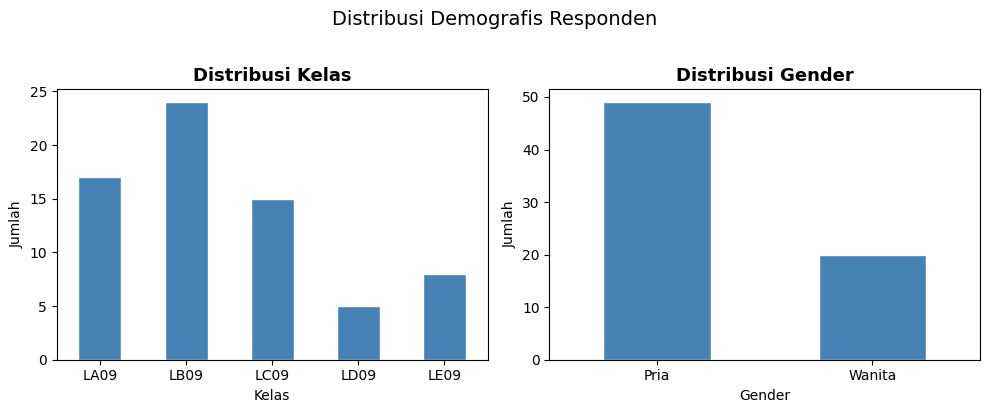

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['Kelas', 'Gender']):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Demografis Responden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

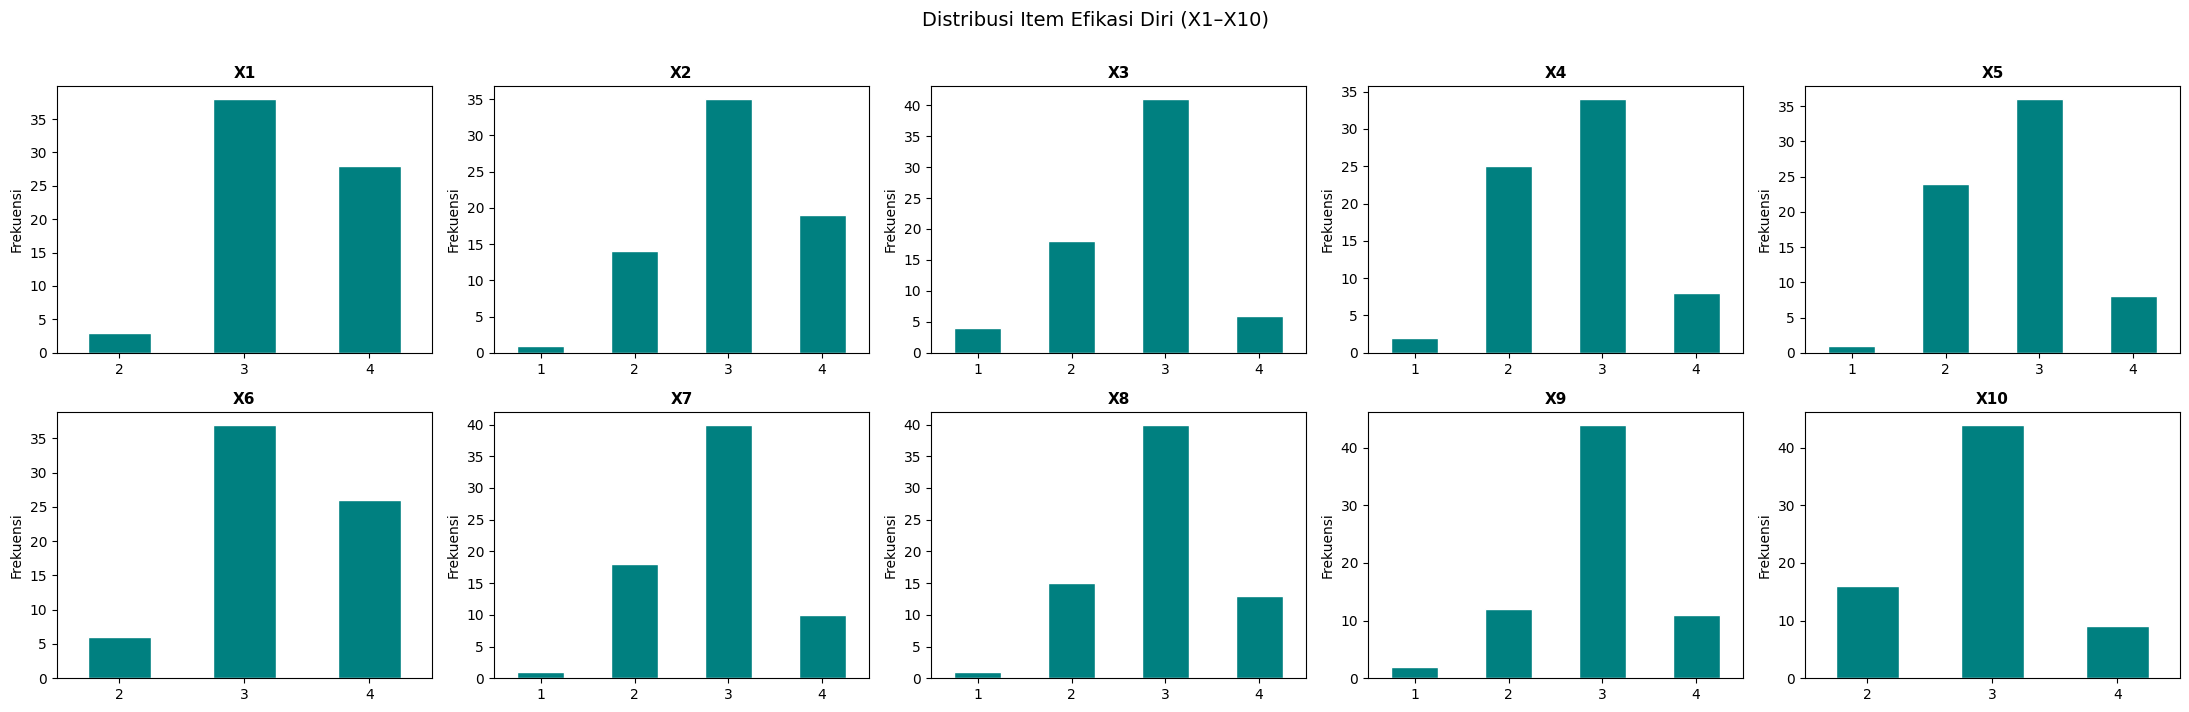

In [52]:
# Distribusi item X (efikasi diri)
var_x = df[X_ITEM_COLS]

fig, axes = plt.subplots(2, 5, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='teal', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Efikasi Diri (X1–X10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

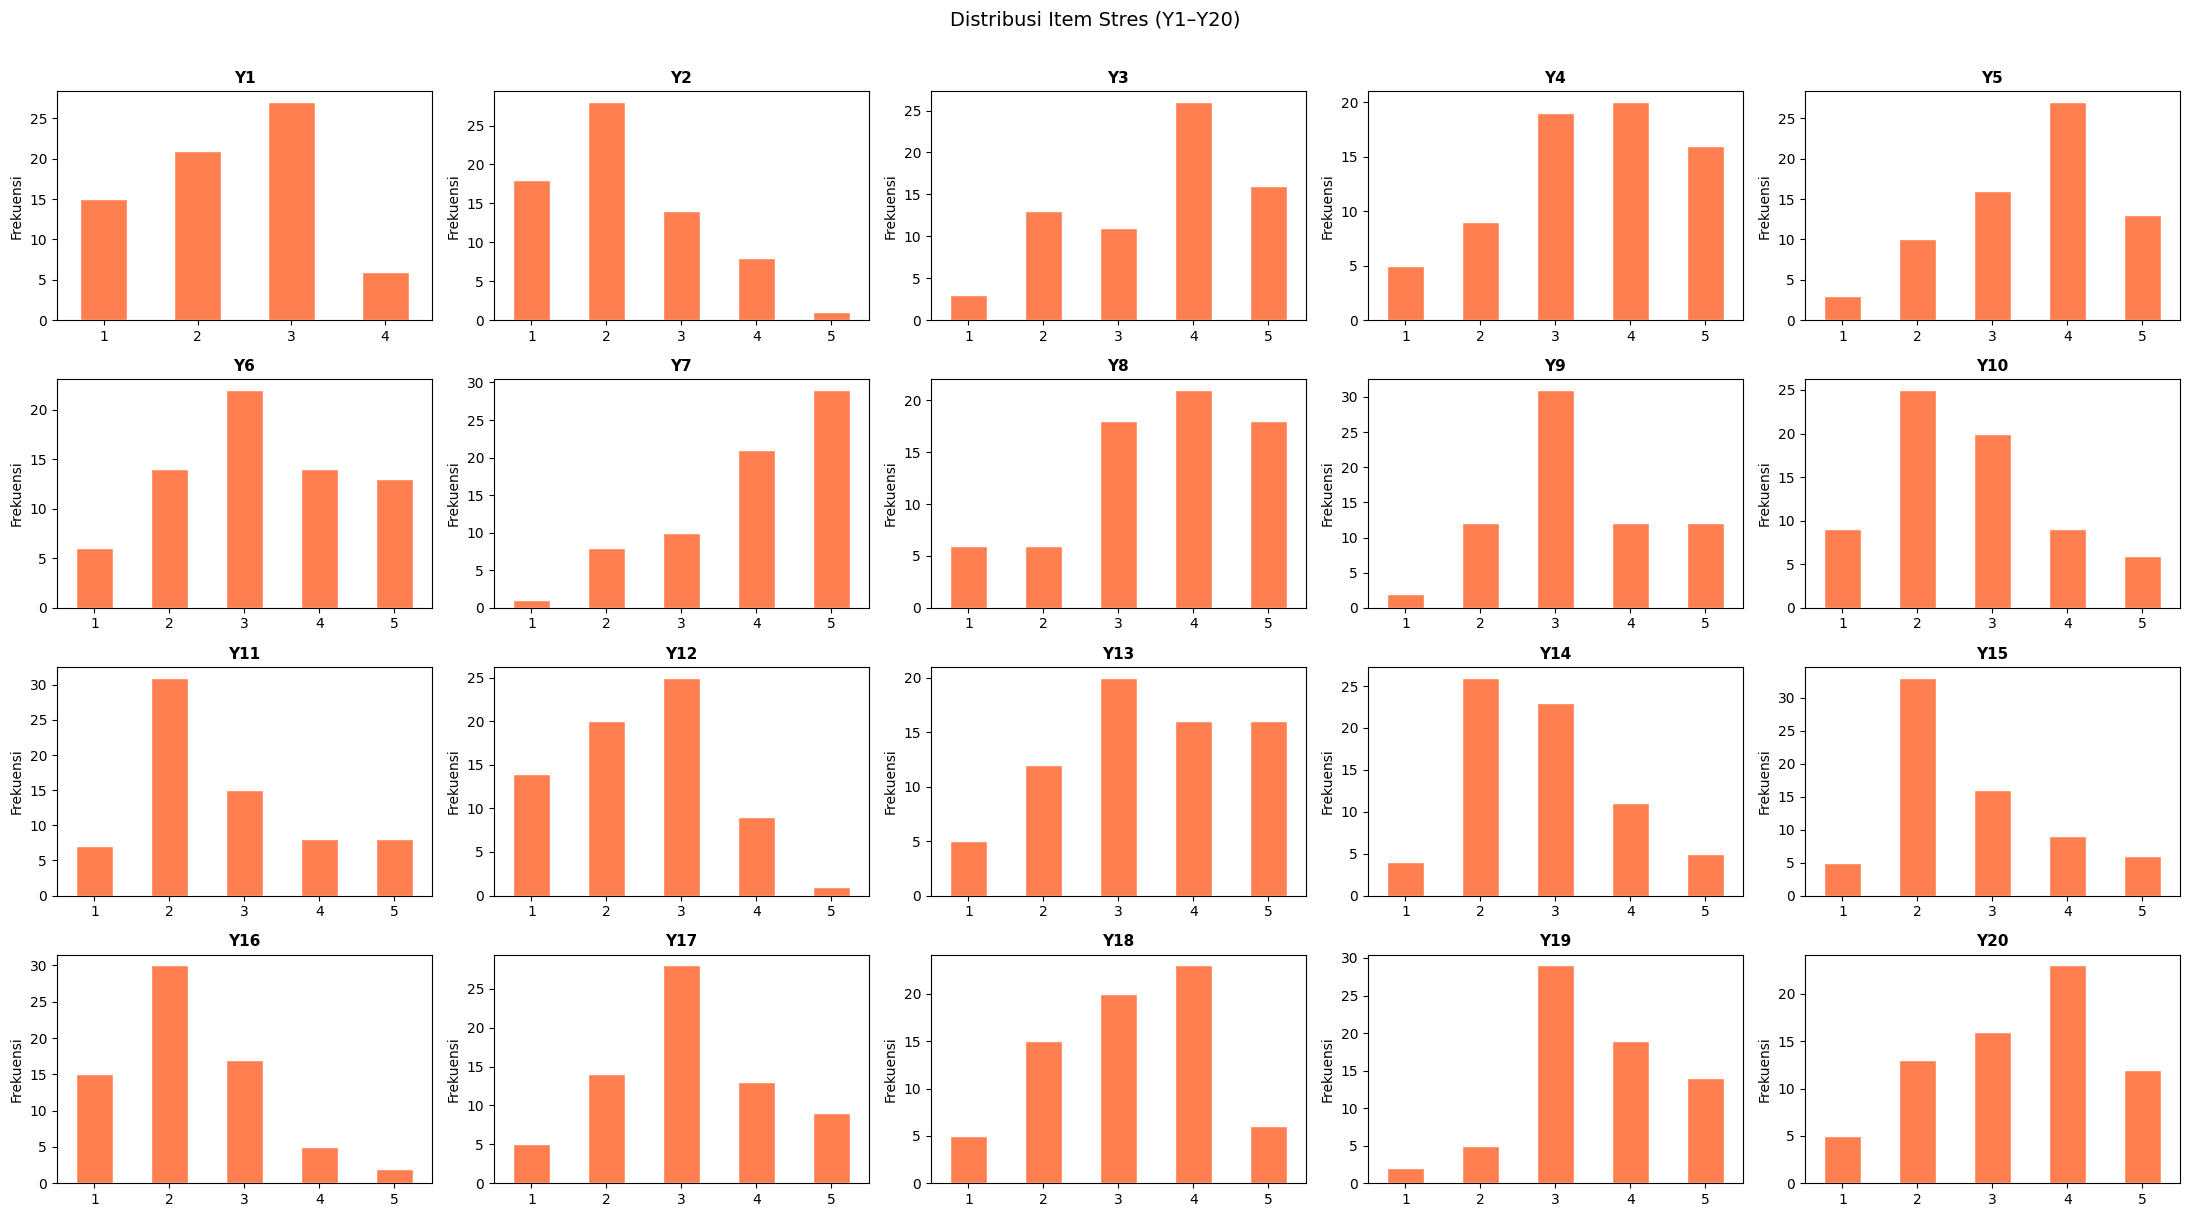

In [53]:
# Distribusi item Y (stres)
fig, axes = plt.subplots(4, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Stres (Y1–Y20)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [54]:
# --- Target utama: rata-rata 20 item Y ---
df['target'] = var_y.sum(axis=1) / 20.0

# --- Faktor-faktor Y ---
for faktor, items in FAKTOR_MAP.items():
    df[faktor] = var_y[items].sum(axis=1) / float(len(items))

# --- Skor efikasi diri agregat ---
df['Efikasi Diri'] = df[X_ITEM_COLS].sum(axis=1) / 4.0   # skala 1-4 → dinormalisasi

print('Kolom setelah feature engineering:')
print(list(df.columns))

Kolom setelah feature engineering:
['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']


In [55]:
# ── Siapkan 3 dataframe untuk 3 varian model ──────────────────────────────────

FAKTOR_COLS = list(FAKTOR_MAP.keys())

# Model 1 — 10 item X + Kelas + Gender → target (Y mean)
df_1 = df.drop(columns=FAKTOR_COLS + ['Efikasi Diri'])

# Model 2 — X_mean + Kelas + Gender → target (Y mean)
df_2 = df.drop(columns=X_ITEM_COLS + FAKTOR_COLS)

# Model 3 — X_mean + Kelas + Gender → tiap Faktor Y (5 model)
df_3 = df.drop(columns=X_ITEM_COLS + ['target'])

for label, d in [('df_1', df_1), ('df_2', df_2), ('df_3', df_3)]:
    print(f'{label}: {d.shape}  |  kolom: {list(d.columns)}')
    print()

df_1: (69, 13)  |  kolom: ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target']

df_2: (69, 4)  |  kolom: ['Kelas', 'Gender', 'target', 'Efikasi Diri']

df_3: (69, 8)  |  kolom: ['Kelas', 'Gender', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']



## 6. Helper Functions

In [56]:
def build_pipeline() -> Pipeline:
    """Buat pipeline LinearRegression dengan OHE untuk kolom kategoris."""
    prep = ColumnTransformer([
        ('ohe',   OneHotEncoder(drop='first', sparse_output=False), OHE_COLS),
        ('pass',  'passthrough', slice(len(OHE_COLS), None))          # kolom numerik sisanya
    ])
    return Pipeline([('preprocessor', prep), ('lr', LinearRegression())])


def fit_and_evaluate(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series,
                     label: str = '', cv: int = 5) -> dict:
    """Fit model, hitung metrik in-sample & CV-R², kembalikan dict hasil."""
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)

    cv_r2 = cross_val_score(pipeline, X, y, cv=cv, scoring='r2').mean()

    result = {
        'Label'  : label,
        'MAE'    : round(mean_absolute_error(y, y_pred),  4),
        'MSE'    : round(mean_squared_error(y, y_pred),   4),
        'RMSE'   : round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        'R²'     : round(r2_score(y, y_pred),             4),
        'CV-R²'  : round(cv_r2,                           4),
    }
    return result, y_pred


def get_coef_df(pipeline: Pipeline, X: pd.DataFrame) -> pd.DataFrame:
    """Ambil nama fitur & koefisien dari pipeline yang sudah di-fit."""
    # Dapatkan nama fitur output dari preprocessor
    try:
        ohe_names  = pipeline.named_steps['preprocessor']\
                         .named_transformers_['ohe']\
                         .get_feature_names_out(OHE_COLS)
    except Exception:
        ohe_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

    num_cols   = [c for c in X.columns if c not in OHE_COLS]
    feat_names = list(ohe_names) + num_cols

    coef = pipeline.named_steps['lr'].coef_
    intercept = pipeline.named_steps['lr'].intercept_
    return pd.DataFrame({'Fitur': feat_names[:len(coef)],
                         'Koefisien (×100)': (coef[:len(feat_names)] * 100).round(2)})\
             .sort_index(), intercept


def print_metrics(result: dict):
    print(f"  MAE   : {result['MAE']}")
    print(f"  MSE   : {result['MSE']}")
    print(f"  RMSE  : {result['RMSE']}")
    print(f"  R²    : {result['R²']}")
    print(f"  CV-R² : {result['CV-R²']}  (5-fold)")


print('✅ Helper functions siap.')

✅ Helper functions siap.


## 8. Model 2 — X Mean + Kelas + Gender → Y Mean

$$Y_{\text{mean}} = \beta_0 + \beta_1\,X_{\text{mean}} + \beta_2\, D_{\text{Kelas}} + \beta_3\,D_{\text{Gender}}$$

In [59]:
X2 = df_2.drop(columns=['target'])
y2 = df_2['target']

X2 = X2[OHE_COLS + [c for c in X2.columns if c not in OHE_COLS]]

pipe2   = build_pipeline()
result2, y_pred2 = fit_and_evaluate(pipe2, X2, y2, label='Model 2')

print('=== Model 2 – Metrik ===')
print_metrics(result2)

=== Model 2 – Metrik ===
  MAE   : 0.3904
  MSE   : 0.2538
  RMSE  : 0.5038
  R²    : 0.1621
  CV-R² : -0.0589  (5-fold)


In [60]:
coef2, intercept2 = get_coef_df(pipe2, X2)
print('=== Model 2 – Koefisien ===')
display(coef2)
print("Intercept:", intercept2.round(2))

=== Model 2 – Koefisien ===


,Fitur,Koefisien (×100)
0,Gender_Wanita,16.46
1,Kelas_LB09,0.78
2,Kelas_LC09,27.04
3,Kelas_LD09,-2.09
4,Kelas_LE09,-11.44
5,Efikasi Diri,-16.02


Intercept: 4.15


$$Y = 4.15 - 16.02 X_{mean} + 0.78 D_{LB09} + 27.04 D_{LC09} - 2.09 D_{LD09} - 11.44 D_{LE09} + 16.46 D_{Wanita}$$

In [ ]:
X2_encoded = pd.get_dummies(X2, columns=['Gender', 'Kelas'], drop_first=True)
X2_encoded = X2_encoded.astype(float)

X2 = sm.add_constant(X2_encoded)  # tambah intercept

model = sm.OLS(y2, X2).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1.998
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0794
Time:                        22:23:27   Log-Likelihood:                -50.606
No. Observations:                  69   AIC:                             115.2
Df Residuals:                      62   BIC:                             130.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.1515      0.429      9.684

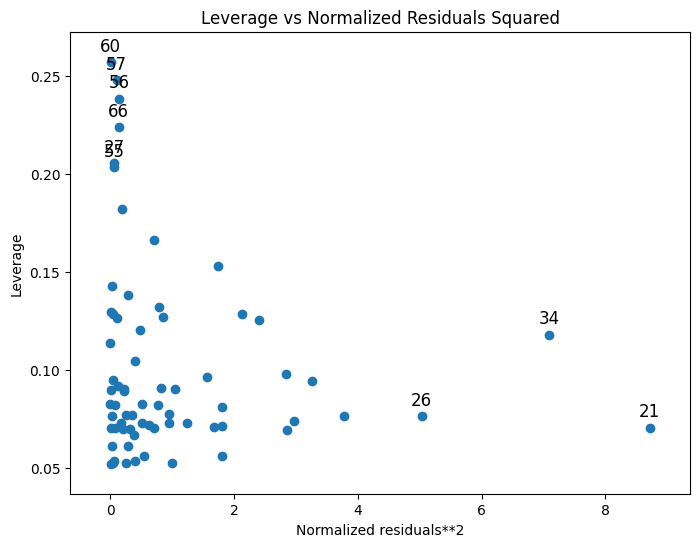

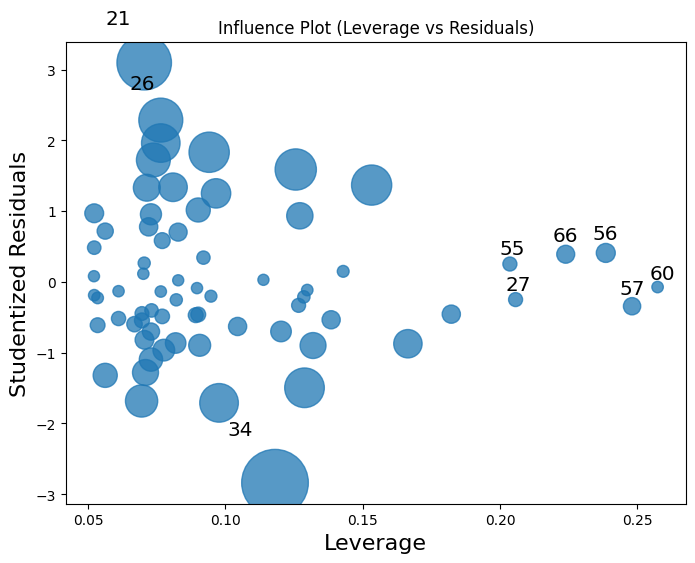

In [76]:
fig, ax = plt.subplots(figsize=(8, 6), num=1)
sm.graphics.plot_leverage_resid2(model, ax=ax) 
plt.title("Leverage vs Normalized Residuals Squared")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6), num=2)
sm.graphics.influence_plot(model, ax=ax)
plt.title("Influence Plot (Leverage vs Residuals)")
plt.show()

$$Y = 4.15 - 0.1602 X_{mean} + 0.0078 D_{LB09} + 0.2704 D_{LC09} - 0.0209 D_{LD09} - 0.1144 D_{LE09} + 0.1646 D_{Wanita}$$